In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("OnlineRetail.csv", encoding="latin1")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
print("shape:",df.shape)

shape: (541909, 8)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [6]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_cols)

Index(['Quantity', 'UnitPrice', 'CustomerID'], dtype='str')


In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='str')


C:\Users\Admin\AppData\Local\Temp\ipykernel_9720\358451199.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [8]:
for col in df.columns:
    print(col, ":", df[col].nunique())

InvoiceNo : 25900
StockCode : 4070
Description : 4223
Quantity : 722
InvoiceDate : 23260
UnitPrice : 1630
CustomerID : 4372
Country : 38


The dataset contains:
numerical columns:quantity,unitprice,customerid.
categorical columns:invoiceno,stockcode,description,invoivedate,country
No single primary key exists

In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df = df.dropna()
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Missing values in the dataset include: customerID:135080 and Description 1454
Missing values were removed because missing values can affect the accuracy of analysis and visualization


In [12]:
duplicates = df.duplicated().sum()
print(duplicates)

5225


In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

Duplicate records were identified. 
findings:5,225 duplicates were found. 
Duplicate records were removed because duplicate records can distort analysis results and lead to inaccurate insights.

In [15]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [16]:
df['Description'] = df['Description'].str.upper()
df['Country'] = df['Country'].str.title()

In [17]:
df = df[df['Quantity'] > 0]

In [18]:
df = df[df['UnitPrice'] > 0]

In [19]:
df['Sales'] = df['Quantity'] * df['UnitPrice']

In [20]:
df.to_csv("Cleaned_Online_Retail.csv",index=False)

Some rows contained uantity values less than or equal to zero
some rows contained unitprice values less than or equal to zero
Rows with invalid quantity and unitprice values were removed
Reason: Negative or zero values do not represent valid sales transactions.

# Cleaning Summary
| Issue Found |	Action Taken |
|-------------|--------------|
| Missing Values |	Removed rows with missing CustomerID and Discription |
| Duplicate Records |	Removed 5268 duplicate rows |
| Invalid Values | Removed rows with quantity < o and unitprice < 0 |
| Date Format |	Converted invoicedate to datetime format |
| Text Standardization | standardized text formating where necessary |




In [21]:
df[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,392692.000000,392692.000000
mean,13.119702,3.125914
std,180.492832,22.241836
min,1.000000,0.001000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,8142.750000


In [22]:
df[['Quantity', 'UnitPrice']].median()

Quantity     6.00
UnitPrice    1.95
dtype: float64

## Summary Statistics
The numerical variables Quantity and UnitPrice were analyzed using descriptive statistics including mean, median, minimum,maximum and standard deviation

In [23]:
top_products = df.groupby('Description') ['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


## Top_Selling Products
The products with the highest total quantity sold were identified.

In [24]:
df['Sales'] = df['Quantity'] * df['UnitPrice']

In [25]:
Country_Sales = df.groupby('Country') ['Sales'].sum().sort_values(ascending=False).head(10)
print(Country_Sales)

Country
United Kingdom    7285024.644
Netherlands        285446.340
Eire               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Sales, dtype: float64


## Revenue by Country
Countries were ranked based on total revenue generated, with United Kingdom generate the highest revenue.

In [26]:
df['InvoiceDate'].dtype

dtype('<M8[us]')

In [27]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [28]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [29]:
Monthly_Sales = df.groupby('Month') ['Revenue'].sum()
print(Monthly_Sales)

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64


## Monthly Sales Trend
Sales performance was analyzed over time to identify seasonal patterns

In [30]:
Most_Purchased = df.groupby('Description') ['Quantity'].sum().sort_values(ascending=False).head(10)
print(Most_Purchased)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


## Most Purchased Products
The most purchased is the paper craft, little birdie with a quantity of 80995

In [31]:
Most_Purchased = df.groupby('Description') ['Quantity'].sum().sort_values(ascending=False).head(10)
print(Most_Purchased)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


In [32]:
Customer_Spending = df.groupby('CustomerID') ['Sales'].sum().sort_values(ascending=False).head(10)
print(Customer_Spending)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Sales, dtype: float64


## Customer Purchasing Behavior
Customer spending patterns were analyzed to identify the highest_value customers.

In [33]:
import matplotlib.pyplot as plt

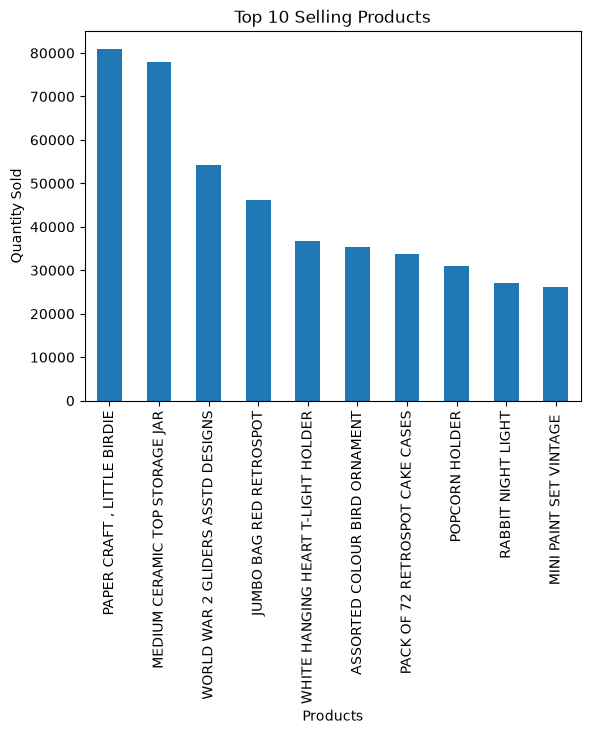

In [34]:
Top_Products = df.groupby('Description') ['Quantity'].sum().sort_values(ascending=False).head(10)
Top_Products.plot(kind='bar')
plt.title('Top 10 Selling Products')
plt.xlabel('Products')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=90)
plt.show()

The chart shows the ten products with the highest sales quantity in the Oneline Retail dataset. The product oaoer craft, little birdie emerged as the best -selling item followed by other items like medium ceramic top storage jar and world war 2 gliders asstd designs

In [35]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

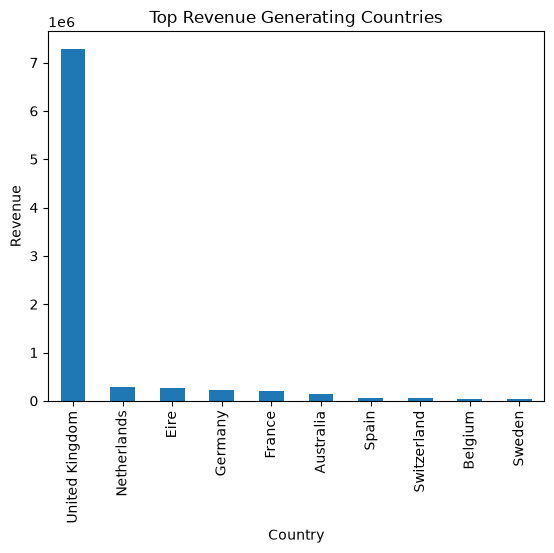

In [36]:
Country_Revenue = df.groupby('Country') ['Revenue'].sum().sort_values(ascending=False).head(10)
Country_Revenue.plot(kind='bar')
plt.title('Top Revenue Generating Countries')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.show()

This bar chart shows the countries that generated the highest total revenue from online retail sales. Revenue was calculated by multiplying quantity sold by unit price and aggregating the results by country. United Kingdom generated by far the highest revenue and is significantly higher than the other country.

In [37]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [38]:
Monthly_Sales = df.groupby('Month') ['Revenue'].sum()
print(Monthly_Sales)

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64


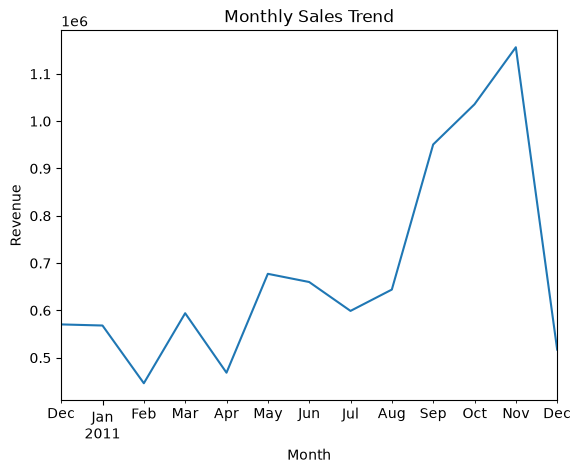

In [40]:
Monthly_Sales.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

This line chart illustrates the monthly revenue generated throughout the year. it helps identify seasonal partterns and periods of high or low sales performance. Monthly revenue increased significantly in the last quarter of the year,with november recording the highest sales.This suggests that customer demand was strongest during the holiday season.

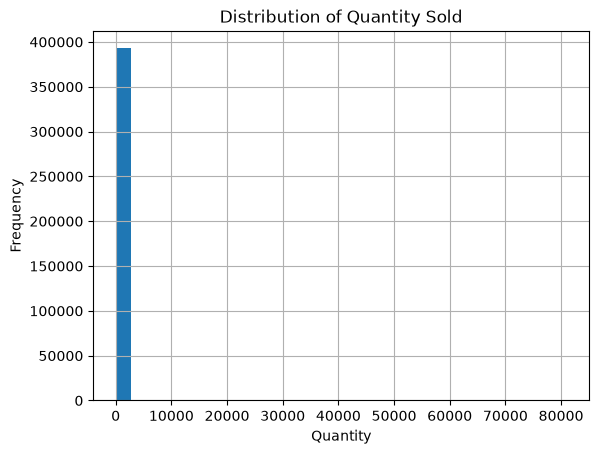

In [41]:
df['Quantity'].hist(bins=30)
plt.title('Distribution of Quantity Sold')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

The quantity sold distribution is highly right-skewed, indicating the that most transactions involve small purchase quantities. Howwever, a few transactions contain exceptionally large quantities creating outliers in the dataset. This suggests that while retail purchases dominate the sales records, occasional bulk or wholesale orders contribute significantly to overall sales volume.

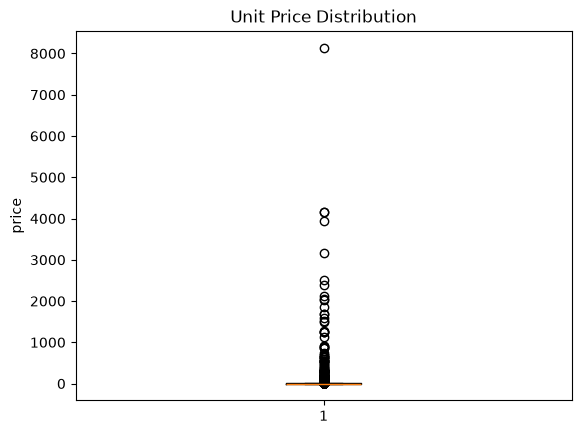

In [42]:
plt.boxplot(df['UnitPrice'])
plt.title('Unit Price Distribution')
plt.ylabel('price')
plt.show()

Most products are sold within a relatively narrow price range, but several extreme price values are present. These outliers may represent premium products,data_entry errors,refunds or special transactions. The presence of these extreme values suggests that the average unit price maybe influenced by a small number of unusually priced products.

# INSIGHTS
1. High demand products contribute significantly to overall sales and should be prioritized in inventory planning and promotional activities
2. The business heavily depends on the UK market, highlighting both a strong customer base and an opportunity to expand revenue streams in other regions.
3. Customer purchasing activity is seasonal, with stronger sales performance observered during the holiday period.
4. Most transactions involved small purchase quantities, while a few bulk orders created outliers in the quantity distribution.
5. The dataset contains in both quantity and unit price, which may represent bulk purchases, wholesale transactions,returns or data-entry anomalies

# SUMMARY REPORT
# Data Cleaning Challenges
The major data_cleaning challenges included handling missing values in the customerID column, removing duplicate records, addressing negative quantities and prices, standardizing date formats, and evaluating outliers in sales quantities and product prices. These issues were resolved to improve data quality and ensure reliable analysis.
# Key EDA Findings
1. Top-Selling products accounted for a significant portion of total sales , with paper craft little birdie emerging as the highest selling product by quantity
2. The United Kingdom was the highest revenue_generating country, contributing substantially more revenue than the other countries in the dataset
3. Sales revenue increased significantly toward the end of the year, with the highest sales recorded in november, indicating strong seasonal demand.
4. Most transactions involved small purchase quantities, while a few bulk purchases created extreme values and outliers in the data
5. The dataset contains 392,692 transaction records, most customers purchased small quantities with a median of 6 units per transaction.
# Top Insights
1. Customer purchases ere generally small and low-priced, but a small number of bulk orders and high-value products contributed disprportionately to overall sales performance
2. High demand products contribute significantly to overall sales and should be prioritized in inventory planning and promotional activities.
3. The business heavily depends on the UK market, highlighting both a strong customer base and an opportunity to expand revenue streams in other regions.
4. Customer purchasing activity is seasonal, with stronger sales performance observered during the holiday period.
5. Most transactions involved small purchase quantities, while a few bulk orders created outliers in the quantity distribution.
6. The dataset contains in both quantity and unit price, which may represent bulk purchases, wholesale transactions,returns or data-entry anomalies

Conclusion:The analysis highlights key opportunities for improving inventory planning,sales strategies, and market focus.
